# Evolutionary Factor Researcher — a **live** mini-run

The companion notebook `evolutionary_factor_researcher_walkthrough.ipynb` dissects
every part on a *synthetic* panel with the LLM calls switched **off**, so it stays
free and deterministic.  This notebook is the opposite: a **tiny end-to-end run of
the real machine**, so every stage can be watched as it actually turns —

* **real LLM calls** — brainstorm → codegen → reflection → mutation, all against
  the live model (`gpt-4o-mini` by default),
* **a pre-settled book** — a Lasso-selected subset of the existing
  `yfinance_equity_sp100` factors is loaded as fixed context, and
* **real ML fitting** — every candidate is scored by the deterministic
  `research_eval` harness, which combines the fixed book's factor signals into one
  forward-return forecast and measures the candidate's **marginal out-of-sample
  IC** (LOCO), residual IC, CPCV robustness, deflation, and the hard gates,

on a small slice of **real S&P-100 daily data** (served offline from the local
`yfinance` parquet cache — no network needed for the data).

> **The one invariant of the whole design:** the LLM *mutates*, the deterministic
> harness *scores*.  No LLM output ever reaches the reward channel except as code
> to compile — so the model can never influence its own fitness.

The core loop runs **twice** — once under the default **NSGA-II** selection (which
converges onto a Pareto front) and once under **Quality-Diversity** selection (which
fills a diverse behaviour grid).  The later sections then switch on the knowledge
layer: a focused **GraphRAG** knowledge graph is built from the paper library (§13), a
**steered researcher session** is given a plain-English brief and grounded in the
matching papers (§14), and the cross-run **experience memory** of what worked and what
didn't is read back (§15).  Together it all makes a few dozen cheap API calls and
takes a few minutes.


## 0 · Setup — keys, data cache, run knobs


In [1]:
import os, sys, json, time, textwrap, logging
import pandas as pd
from pathlib import Path

# --- locate the repo root (the dir that contains quant_fund_agent/) ---
here = Path.cwd()
ROOT = next((p for p in [here, *here.parents] if (p / "quant_fund_agent").is_dir()), None)
assert ROOT is not None, "run this from inside the QuantFundAgent repo"
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

# --- load the OpenAI key from the repo's .env by EXPLICIT path ---
# (load_dotenv() with no arg resolves relative to *this file's* dir, which for a
#  notebook is notebooks/ — so we point it straight at the repo-root .env.)
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

# --- run in-process (identical maths to the MCP server) + free embeddings ---
os.environ["QF_USE_MCP"]     = "0"      # evaluate candidates in-process
os.environ["QF_EMBEDDER"]    = "hash"   # no embedding API needed (RAG is off here)
os.environ["QF_FUNDAMENTALS"] = "0"     # OHLCV-only → fast, fully offline data

# --- surface the evolution loop's own logging inside the notebook ---
logging.basicConfig(level=logging.INFO, format="%(name)-18s %(message)s", stream=sys.stdout)
for noisy in ("httpx", "openai", "urllib3", "httpcore"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

from quant_fund_agent.llm import resolve_research_model
MODEL = resolve_research_model()
has_key = bool(os.getenv("OPENAI_API_KEY"))

# cached tickers available offline
cache = ROOT / "data/market/yfinance/equity/1d"
n_cached = len(list(cache.glob("*.parquet"))) if cache.exists() else 0

print("repo root      :", ROOT)
print("OPENAI_API_KEY :", "present ✅" if has_key else "MISSING ❌ (LLM cells will fail)")
print("research model :", MODEL)
print("cached tickers :", n_cached, "(offline yfinance daily bars)")

repo root      : /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent
OPENAI_API_KEY : present ✅
research model : gpt-4o-mini
cached tickers : 102 (offline yfinance daily bars)


The knobs below keep this run **small on purpose**.  The exact same objects, scaled
up, are what `run_factor_evolution.py` drives for a thesis run.


In [2]:
N_TICKERS   = 8     # universe slice for the live demo scoring/evolution cells
FIELDS      = ["open", "high", "low", "close", "volume"]
HORIZON     = 6     # forecast/IC horizon in bars (daily → ~6 trading days)
DATA_DIR    = "ticker_data"   # ignored for yfinance (cache is keyed by config), kept for the API
SEED        = 7

WORKSPACE   = ROOT / "data/workspaces/yfinance_equity_sp100"
PREBOOK_PATH = WORKSPACE / "prebooks/lasso_prebook.json"
PREBOOK_MAX_FACTORS = 12       # live-demo cap; set to None in the builder to keep every non-zero Lasso name
PREBOOK_MAX_ROWS = 50_000

# a scratch dir for this run's checkpoints, OUTSIDE the repo (nothing is written
# into data/workspaces/ by the evolution loop itself, and nothing clutters git)
import tempfile
SCRATCH = Path(tempfile.gettempdir()) / "qfa_live_demo_evolution"
SCRATCH.mkdir(parents=True, exist_ok=True)

# keep the evolution loop's cross-run EXPERIENCE MEMORY inside the scratch dir too, so
# the "what worked / what didn't" graph the runs accrue (see §15) never clutters the repo.
from quant_fund_agent.knowledge import experience
experience.MEMORY_ROOT = SCRATCH / "memory"
MEMORY_CONFIG = "live_demo_sp100"     # per-config memory key (S&P100 vs LOBSTER never share)

print("scratch out_dir:", SCRATCH)
print("memory dir     :", experience.MEMORY_ROOT)
print("prebook path   :", PREBOOK_PATH)


scratch out_dir: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution
memory dir     : /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory
prebook path   : /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/data/workspaces/yfinance_equity_sp100/prebooks/lasso_prebook.json


## 1 · The real data panel

Everything downstream reads this one dict of `field -> DataFrame(index=dates,
columns=tickers)`.  It is loaded through the project's data layer, which resolves
the active `quant.config.yaml` (a `yfinance` S&P-100 config) and serves the bars
straight from the parquet cache.


In [3]:
from quant_fund_agent.data import load_panel

panel = load_panel(DATA_DIR, fields=FIELDS, n_tickers=N_TICKERS)
close = panel["close"]
print("fields loaded :", sorted(panel))
print("close panel   :", close.shape, "= (bars, tickers)")
print("tickers       :", list(close.columns))
print("date range    :", close.index.min().date(), "→", close.index.max().date())
close.tail(3)

fields loaded : ['close', 'high', 'low', 'open', 'volume']
close panel   : (1625, 8) = (bars, tickers)
tickers       : ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMD', 'AMGN']
date range    : 2020-01-02 → 2026-06-22


,AAPL,ABBV,ABT,ACN,ADBE,AIG,AMD,AMGN
Date,,,,,,,,
2026-06-17,295.950012,221.229996,88.500000,156.009995,196.279999,74.769997,512.479980,341.660004
2026-06-18,298.010010,216.490005,88.410004,127.980003,195.160004,74.019997,537.369995,337.600006
2026-06-22,297.010010,230.009995,87.830002,124.830002,194.899994,76.370003,551.630005,344.720001


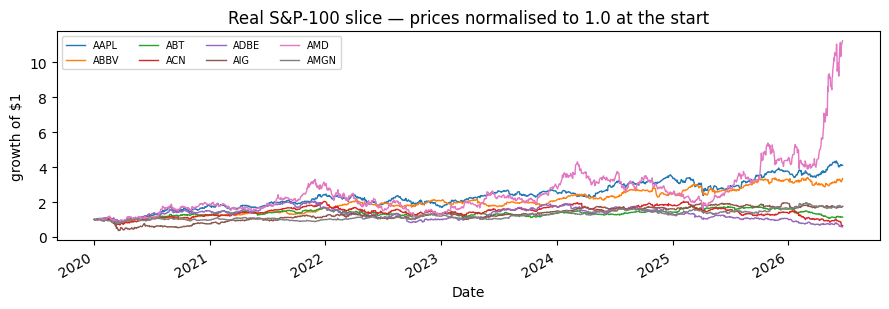

In [4]:
# a quick look at the raw material: normalised price paths for the slice
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 3.2))
(close / close.iloc[0]).plot(ax=ax, lw=1)
ax.set_title("Real S&P-100 slice — prices normalised to 1.0 at the start")
ax.set_ylabel("growth of $1"); ax.legend(ncol=4, fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 2 · The data contract the LLM is given

Before any brainstorming, the researcher builds a **data context** — the exact
menu of fields the model is allowed to touch (anything off-menu makes a factor
*out-of-scope* and it is dropped).  It also carries a bar-size-aware **horizon
contract** so the model picks a sensible `prediction_horizon`.  This is the same
`build_data_context` the production pipeline uses.


In [5]:
from quant_fund_agent.agents.factor_research.prompts import build_data_context

# infer seconds-per-bar straight from the real panel index (daily ≈ 86400 s)
_dt = close.index.to_series().diff().dropna().dt.total_seconds()
seconds_per_bar = float(_dt.median()) if len(_dt) else None

DATA_CONTEXT = build_data_context(sorted(FIELDS), seconds_per_bar)
print(f"(inferred seconds/bar = {seconds_per_bar:,.0f}  →  ~{seconds_per_bar/86400:.0f} day bars)\n")
print(DATA_CONTEXT)

(inferred seconds/bar = 86,400  →  ~1 day bars)

You are working with the configured market-data feed (daily bars).  When you write a factor, the ``data``
dict passed to ``calc`` exposes the fields below as ``pd.DataFrame``
(index = bar timestamps, columns = tickers).  Every field below is
available — pick whichever ones your idea actually needs; do NOT use any
field that is not listed (the factor would be rejected as out-of-scope).

Price / OHLCV view:

    open      : start-of-bar price (mid-price on LOBSTER)
    high      : intra-bar high (max(mid, midEnd) on LOBSTER)
    low       : intra-bar low (min(mid, midEnd) on LOBSTER)
    close     : end-of-bar price (mid-price on LOBSTER)
    volume    : traded volume in the bar (|signed trade| on LOBSTER)

Notes:
- All fields are aligned on the same DatetimeIndex and the same ticker
  columns, so cross-field arithmetic is safe.
- Do NOT pass extra keyword arguments to the helper operators below —
  they take positional arguments only.

PR

## 3 · The pre-settled Lasso book

The residual and marginal-value axes only become meaningful once the candidate is
conditioned on a non-empty book.  For this live run the book is **fixed context**:
it is not inserted into the evolutionary archive and it will not be persisted as a
new discovery.  It simply gives the evaluator something real to residualise
against.

The JSON artifact below was built from all factor records in
`data/workspaces/yfinance_equity_sp100` by fitting a Lasso model to predict the
horizon-6 forward return.  The live notebook keeps the top 12 Lasso coefficients
so scoring stays quick; the builder can be rerun with a different cap for larger
experiments.


In [6]:
from quant_fund_agent.research_eval.prebook import (
    book_entries,
    fit_lasso_prebook,
    load_prebook,
    load_workspace_programs,
    save_prebook,
)

if PREBOOK_PATH.exists():
    prebook = load_prebook(PREBOOK_PATH)
else:
    # Slow path: only runs if the reusable artifact is missing.
    programs, load_dropped = load_workspace_programs(WORKSPACE)
    prebook = fit_lasso_prebook(
        programs, panel,
        target_horizon=HORIZON,
        max_rows=PREBOOK_MAX_ROWS,
        max_members=PREBOOK_MAX_FACTORS,
        seed=SEED,
    )
    prebook["workspace"] = str(WORKSPACE)
    prebook["load_dropped"] = load_dropped
    prebook["fields"] = FIELDS
    prebook["n_tickers"] = N_TICKERS
    save_prebook(prebook, PREBOOK_PATH)

assert prebook.get("ok"), prebook.get("error", "prebook build failed")
PRESETTLED_BOOK = book_entries(prebook)
assert PRESETTLED_BOOK, "Lasso prebook is empty; widen/relax the Lasso selection before scoring residual effects"

prebook_df = pd.DataFrame([
    {
        "rank": f.get("rank"),
        "factor_id": f["factor_id"],
        "coef": f.get("coefficient"),
        "importance": f.get("importance"),
        "source": f.get("source_prerun"),
    }
    for f in prebook.get("factors", [])
])

print(f"pre-settled book : {len(PRESETTLED_BOOK)} factor(s)")
print(f"source factors   : {prebook.get('n_usable')}/{prebook.get('n_candidates')} usable; "
      f"{prebook.get('n_lasso_nonzero')} non-zero Lasso coefficients")
print(f"lasso alpha      : {prebook.get('alpha')} ({prebook.get('alpha_source')})")
print(f"artifact         : {PREBOOK_PATH}")
prebook_df


pre-settled book : 12 factor(s)
source factors   : 210/218 usable; 208 non-zero Lasso coefficients
lasso alpha      : 1e-05 (fallback_min_alpha)
artifact         : /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/data/workspaces/yfinance_equity_sp100/prebooks/lasso_prebook.json


,rank,factor_id,coef,importance,source
0,1,relative_volume_price_momentum,0.335640,0.168458,sp100-4o-mini
1,2,price_momentum_with_volume_adjustment,-0.301905,0.151527,sp100-4o-mini
2,3,range_liquidity_load_bearing,-0.208137,0.104464,sp100-5.4-mini
3,4,trade_volume_excess_momentum,0.180020,0.090352,sp100-4o-mini
4,5,price_dislocation_indicator,-0.179474,0.090078,sp100-4o-mini
5,6,range_settlement_efficiency,0.123126,0.061797,sp100-5.4-mini
6,7,relative_intrabar_recovery_momentum,0.118596,0.059524,sp100-5.4-mini
7,8,intermittent_volume_momentum,-0.114523,0.057479,sp100-4o-mini
8,9,price_impact_to_volume_ratio,-0.111647,0.056036,sp100-4o-mini
9,10,range_skew_impulse,-0.106968,0.053687,sp100-5.4-mini


## 4 · Seeding, step 1 — **brainstorm** (live LLM)

Generation 0 comes from the *same* brainstorm/codegen path the one-shot baseline
uses, so both arms start from the same generator.  Here we call the real model to
propose a few factor **ideas** — each a structured hypothesis: a mechanism, an
`expected_sign`, and a chosen `prediction_horizon`.  Nothing is scored yet.


In [7]:
from quant_fund_agent.agents.factor_research.graph import _brainstorm_one
from quant_fund_agent.llm import make_chat_llm

brainstorm_llm = make_chat_llm(temperature=0.7, timeout=120, max_retries=3)

t0 = time.time()
raw_ideas = _brainstorm_one(brainstorm_llm, paper=None, n_ideas=3,
                            known_ids=set(), session_id="live-demo",
                            data_context=DATA_CONTEXT)
print(f"brainstorm returned {len(raw_ideas)} idea(s) in {time.time()-t0:.1f}s\n")

for i, idea in enumerate(raw_ideas):
    print(f"── idea {i} ─────────────────────────────────────────────")
    print(f"  factor_id  : {idea.get('factor_id')}")
    print(f"  name       : {idea.get('name')}")
    print(f"  category   : {idea.get('category')}")
    print(f"  horizon    : {idea.get('prediction_horizon')}  "
          f"(suggested {idea.get('suggested_horizons')})")
    print(f"  exp. sign  : {idea.get('expected_sign')}")
    print("  idea       :", textwrap.fill(idea.get('trading_idea',''), 92,
                                          subsequent_indent=' '*15))
    print()

factor_research    [session live-demo] brainstorm call (own-knowledge, asked 3, 1061 tok): 9.4s
brainstorm returned 3 idea(s) in 9.4s

── idea 0 ─────────────────────────────────────────────
  factor_id  : price_momentum_with_volume
  name       : Price Momentum Adjusted by Volume
  category   : momentum
  horizon    : 5  (suggested [3, 10, 20])
  exp. sign  : None
  idea       : Price momentum can indicate the strength of a trend, but volume is essential to confirm that
               trend's sustainability. By adjusting the price momentum with a measure of
               trading volume, we can filter out price movements that lack support from
               market participants, potentially leading to higher success rates in trending
               strategies.

── idea 1 ─────────────────────────────────────────────
  factor_id  : mean_reversion_by_high_low_range
  name       : Mean Reversion Based on High-Low Range
  category   : mean_reversion
  horizon    : 10  (suggested [5, 15, 3

## 5 · Seeding, step 2 — **codegen** (live LLM)

Each surviving idea is handed to a lower-temperature model that writes an actual
`BaseFactor` subclass.  The code is compiled **in-memory** and smoke-tested (a
candidate only becomes a file if it survives evolution).  If compilation fails, the
error is fed back for **one self-correcting retry** — the same loop the production
codegen uses.


In [8]:
from quant_fund_agent.agents.factor_research.evolution.loop import _codegen_program, coerce_idea

codegen_llm = make_chat_llm(temperature=0.2, timeout=120, max_retries=3)

seed_prog = {}
for i, raw in enumerate(raw_ideas):
    idea = coerce_idea(raw, HORIZON)
    prog = _codegen_program(codegen_llm, idea, DATA_CONTEXT)   # compiles in-memory
    if prog is None:
        raise RuntimeError(f"codegen failed for idea {i}: {idea.factor_id}")
    seed_prog[i] = prog

    print("compiled factor :", prog.factor_id, "| horizon", prog.prediction_horizon,
          "| expected_sign", prog.expected_sign)
    print("=" * 92)
    print(prog.code)


compiled factor : price_momentum_with_volume | horizon 5 | expected_sign None
"""Price momentum can indicate the strength of a trend, but volume is essential to confirm that trend's sustainability. By adjusting the price momentum with a measure of trading volume, we can filter out price movements that lack support from market participants, potentially leading to higher success rates in trending strategies."""

from __future__ import annotations

import pandas as pd
import numpy as np

from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.ops import delta, adv, ts_mean, sign
from quant_fund_agent.factors.registry import register_factor


@register_factor
class PriceMomentumWithVolume(BaseFactor):
    factor_id = "price_momentum_with_volume"
    name = "Price Momentum Adjusted by Volume"
    category = "momentum"
    description = "This signal computes the momentum of price changes, weighted by the volume traded during the same period. The momentum is calcula

## 6 · The reward channel — **real ML fitting** (no LLM)

Now the deterministic part.  `evaluate_fitness` compiles the candidate, computes
its signal on the panel, and scores it on a **5-axis Pareto vector** against the
pre-settled Lasso book.  The primary axis is **marginal value (LOCO)**: a
**gradient-boosting** model is fit on the in-sample window to combine the fixed
book's signals into one forward-return forecast, and we measure how much the
candidate *adds* to the combined model's **out-of-sample IC**.

Because the book is already non-empty, the second and third seed ideas now show
real residual/orthogonal effects immediately instead of being evaluated as if
they were first in line.  Around marginal value sit four more axes —

- **independence** = the candidate's **residual (orthogonalised) IC** (its edge in
  the direction the book doesn't already span),
- **robustness** (CPCV mean − λ·std, − plateau, + sign bonus),
- **parsimony** (−AST complexity), and
- **regime_independence** = its marginal ΔIC **on the crash/stress bars** — edge
  added exactly where the book is weakest —

behind hard **gates** (coverage / degradation / deflation) a factor must clear.


In [9]:
from quant_fund_agent.mcp import research_client


def _ax(v, nd=4):
    return f"{v:+.{nd}f}" if v is not None else "n/a"


t0 = time.time()
fit = {}
for i, prog in seed_prog.items():
    res = research_client.evaluate_fitness(
        candidate={"factor_id": prog.factor_id, "code": prog.code,
                   "expected_sign": prog.expected_sign},
        book=PRESETTLED_BOOK,          # fixed Lasso book → residual/marginal effects are visible immediately
        jitter=[],                     # (the plateau probe rides along here in a real run)
        target_horizon=HORIZON, is_frac=0.6, val_frac=0.2, n_trials=i + 1,
        cpcv_groups=4, cpcv_k=2, embargo=0,
        data_dir=DATA_DIR, n_tickers=N_TICKERS, fields=FIELDS,
        # nonlinear LOCO combiner (captures conditioning value), residual-IC
        # independence, drawdown regime axis
        marginal_model="gradient_boosting",
        independence_metric="residual_ic", regime_kind="drawdown", regime_quantile=0.2,
    )
    print(f"Factor {prog.factor_id} scored in {time.time()-t0:.1f}s  |  ok = {res['ok']}\n")
    if not res.get("ok"):
        print(res.get("error"))
        print("=" * 92)
        continue

    fit[i] = res["fitness"]
    obj = fit[i]["objective"]
    d = fit[i]["diagnostics"]

    print("── Pareto objective vector (5 axes, all maximised) ─")
    print(f"  base_book_ic  (fixed book OOS IC)        : {_ax(d.get('base_ic'))}")
    print(f"  with_factor_ic(book + candidate OOS IC) : {_ax(d.get('with_ic'))}")
    print(f"  marginal_value (LOCO ΔOOS-IC, primary) : {_ax(obj['marginal_value'])}")
    print(f"  independence   (residual/orthogonal IC): {_ax(obj['independence'])}")
    print(f"  robustness     (CPCV mean−λ·std, …)    : {_ax(obj['robustness'])}")
    print(f"  parsimony      (−AST complexity)       : {_ax(obj['parsimony'], 1)}")
    print(f"  regime_indep.  (ΔIC on crash bars)     : {_ax(obj['regime_independence'])}"
          f"   (stress bars scored: {d.get('n_stress_obs')})")
    print("\n── hard gates ──────────────────────────────────────")
    g = fit[i]["gates"]
    print(f"  passed = {g['passed']}   "
          f"(coverage={g['coverage_ok']}, degradation={g['degradation_ok']}, "
          f"deflation={g['deflation_ok']})")
    if g.get("reasons"):
        for k, v in g["reasons"].items():
            print(f"    ✗ {k}: {v}")
    print("=" * 92)


research.service   Loading panel from ticker_data (fields=['close', 'high', 'low', 'open', 'volume'], n_tickers=8) …


research.service   Panel loaded in 0.1s (8 tickers, 5 fields)
Factor price_momentum_with_volume scored in 5.7s  |  ok = True

── Pareto objective vector (5 axes, all maximised) ─
  base_book_ic  (fixed book OOS IC)        : -0.0092
  with_factor_ic(book + candidate OOS IC) : -0.0124
  marginal_value (LOCO ΔOOS-IC, primary) : -0.0031
  independence   (residual/orthogonal IC): +0.0546
  robustness     (CPCV mean−λ·std, …)    : -0.0365
  parsimony      (−AST complexity)       : -14.0
  regime_indep.  (ΔIC on crash bars)     : -0.0018   (stress bars scored: 376)

── hard gates ──────────────────────────────────────
  passed = False   (coverage=True, degradation=False, deflation=None)
    ✗ degradation: OOS/IS=-0.074 < τ=0.5
Factor mean_reversion_by_high_low_range scored in 10.1s  |  ok = True

── Pareto objective vector (5 axes, all maximised) ─
  base_book_ic  (fixed book OOS IC)        : -0.0092
  with_factor_ic(book + candidate OOS IC) : -0.0087
  marginal_value (LOCO ΔOOS-IC, primary) 

It is completely normal for a first random idea to **fail a gate** (a degradation
gate fires when the edge does not survive out-of-sample).  A failing candidate is
not thrown away silently — its diagnostics become the *teacher signal* for the next
step.


## 7 · Reflection — the deterministic **teacher** (no LLM writes it)

The numeric dashboard is turned into a natural-language **mutation brief** by
rule-based logic — *no LLM writes this*.  Every advice line is triggered by a
threshold on the numbers above.  This brief is the only feedback the mutating LLM
receives about how its parent performed.


In [10]:
from quant_fund_agent.research_eval.fitness import FitnessResult
from quant_fund_agent.agents.factor_research.evolution.reflection import mutation_brief

for i, prog in seed_prog.items():
    if i not in fit:
        continue
    print(f"── reflection for {prog.factor_id} ───────────────────────")
    fitness = FitnessResult.from_dict(fit[i])
    brief = mutation_brief(fitness, book_size=len(PRESETTLED_BOOK))
    print(brief)
    print("=" * 92)


── reflection for price_momentum_with_volume ───────────────────────
VERDICT: FAILED hard gate(s) — degradation: OOS/IS=-0.074 < τ=0.5.
Marginal value (primary axis): adding this factor moved the combined model's OOS IC by -0.0031 (with=-0.0124, book-only=-0.0092, book size=12).
Standalone IC at the target horizon: -0.0011 (IS=+0.0153, VAL=-0.0011).
IC decay across horizons: 1b=-0.0024, 3b=-0.0101, 6b=-0.0011, 12b=-0.0150, 24b=-0.0408.  |IC| peaks at 24 bars (-0.0408).
Independence (axis = residual_ic): residual IC after regressing out the book +0.0546 — the edge the book does NOT already span; Δ participation ratio -0.1978 (book effective factors +3.75 → +3.55); max |corr| to an existing factor: +1.0000.
Robustness: CPCV IC mean -0.0095 ± +0.0269 over 6 purged folds; OOS/IS degradation ratio -0.0738.
Regime (crash-complementarity): marginal ΔIC on the drawdown stress bars -0.0018 (book-with=+0.0157, book-only=+0.0175, n_stress=376) — edge added exactly where the book is weakest.
Compl

## 8 · Mutation — the creative operator (live LLM)

The parent program **plus its reflection brief** are handed back to the LLM, which
proposes a *child* — a genuinely new factor that tries to fix what the brief
flagged.  The child is parsed, its id de-collided, and compiled in-memory (with the
same one-shot feedback retry).  Below we show the parent → child jump.


In [11]:
from quant_fund_agent.agents.factor_research.evolution.mutation import (
    build_mutation_prompt, parse_child_response,
)
from quant_fund_agent.factors.inmem import compile_factor

# Mutate the seed idea with the best marginal value against the fixed book.
parent_i = max(
    fit,
    key=lambda j: fit[j]["objective"].get("marginal_value")
    if fit[j]["objective"].get("marginal_value") is not None else float("-inf"),
)
parent = seed_prog[parent_i]
parent_fitness = FitnessResult.from_dict(fit[parent_i])
parent_brief = mutation_brief(parent_fitness, book_size=len(PRESETTLED_BOOK))
existing_ids = [p.factor_id for p in seed_prog.values()] + [b["factor_id"] for b in PRESETTLED_BOOK]

prompt = build_mutation_prompt(parent, parent_brief, DATA_CONTEXT, existing_ids=existing_ids)

# what the model actually receives (trimmed) — note the brief is embedded verbatim
print("MUTATION PROMPT (excerpt) ".ljust(92, "─"))
print("…parent idea + code + the reflection brief + a strict JSON schema…\n")
print("brief handed to the model:\n" + textwrap.indent(parent_brief.split(chr(10))[0], "    "), "…\n")

resp = brainstorm_llm.invoke(prompt)
child = parse_child_response(getattr(resp, "content", str(resp)))
compile_factor(child.code, child.factor_id, smoke=True)   # validate the child

print("PARENT →", parent.factor_id)
print("  idea :", textwrap.fill(parent.trading_idea or parent.description, 88,
                                subsequent_indent=' '*9))
print("\nCHILD  →", child.factor_id, f"(horizon {child.prediction_horizon}, sign {child.expected_sign})")
print("  idea :", textwrap.fill(child.trading_idea or child.description, 88,
                                subsequent_indent=' '*9))
print("\nchild code:\n" + "=" * 92)
print(child.code)


MUTATION PROMPT (excerpt) ──────────────────────────────────────────────────────────────────
…parent idea + code + the reflection brief + a strict JSON schema…

brief handed to the model:
    VERDICT: passed every hard gate; competing on the Pareto front. …

PARENT → mean_reversion_by_high_low_range
  idea : Assets often experience mean reversion after extreme price movements. By observing the
         range between daily high and low prices, we can identify when an asset has
         deviated from its typical trading range, suggesting a potential reversal. This
         is based on the behavioral finance notion that traders may overreact to news,
         leading to price extremes.

CHILD  → mean_reversion_by_high_low_zscore (horizon 10, sign -1)
  idea : Assets often exhibit mean reversion after extreme price movements. By analyzing the
         z-score of the daily high-low range relative to its historical volatility, we
         can identify overbought or oversold conditions, sugge

## 9 · The whole loop, turning on its own — NSGA-II selection

Sections 3–8 walked a few candidates through a single lap by hand.  `EvolutionLoop`
does exactly that in a cycle: **seed → (select a parent → mutate / crossover / jitter
→ score → insert → reflect)\***.  In the **default** configuration selection is
**constrained NSGA-II**: the gate-passing **Pareto archive** *is* the accepted book,
and parents are drawn from it by tournament, with per-generation checkpoints.

The configuration below is deliberately small (3 generations, a few children each,
5 seed ideas) and has the cross-run **experience memory** switched on — every scored
candidate is tallied against its topic, which §15 reads back.  On its own the loop
only logs a per-generation summary, so a small **trace hook** is attached to the
single admission choke-point.  It prints **every candidate the moment it is scored** —
the operator that produced it, its five Pareto axes, the behaviour coordinates the
harness measured, and whether it cleared the hard gates.  Interleaved with the loop's
own brainstorm and seeding logs, this is the machine's real inner workings, generation
by generation.  `n_trials` is the deflation counter: every *scored* look is billed, so
the multiple-testing statistics stay honest.


In [12]:
import sys, importlib
for _name in list(sys.modules):
    if (".factor_research.evolution" in _name) or (".research_eval" in _name):
        del sys.modules[_name]

from quant_fund_agent.agents.factor_research.evolution.loop import (
    EvolutionLoop, EvolutionRunConfig,
)

# ── a tiny trace hook so the notebook shows the machine's REAL inner workings ──
# The loop's own logging only reports a per-generation summary.  This wraps the single
# admission choke-point (``_admit_genome``) to print every candidate the instant it is
# scored: the operator that made it, its 5-axis Pareto objective, the behaviour
# coordinates the harness measured, the grid cell it lands in (QD runs only), and
# whether it cleared the hard gates.  Re-used unchanged by the Quality-Diversity run.
def _f(v, nd=4):
    return f"{v:+.{nd}f}" if isinstance(v, (int, float)) else "  n/a "

def attach_trace(loop):
    _orig = loop._admit_genome
    qd = loop.controller.qd                      # set only when selection="qd"
    def _traced(genome):
        eg = _orig(genome)                        # the real evaluation + archive insert
        if eg is None:
            return eg                             # duplicate / eval-failure (already logged)
        o, g, b = eg.fitness.objective, eg.fitness.gates, eg.fitness.behavior
        fid = ",".join(genome.factor_ids)
        verdict = "PASS ✅" if g.passed else "gate ✗ " + next(
            (k[:-3] for k in g.GATES if getattr(g, k) is False), "?")
        cell = f"  cell {qd.cell_key(b)}" if (qd is not None and g.passed) else ""
        print(f"  gen{genome.generation} {genome.operator:11.11} {fid[:30]:30} "
              f"marg {_f(o.marginal_value)} indep {_f(o.independence)} "
              f"robust {_f(o.robustness)} regime {_f(o.regime_independence)} "
              f"| trend {_f(b.get('trend_reversal'), 2)} speed {_f(b.get('signal_speed'), 2)}"
              f"{cell}  {verdict}")
        return eg
    loop._admit_genome = _traced
    return loop

cfg = EvolutionRunConfig(
    generations=3, population_size=8, children_per_generation=3,
    n_seed_ideas=5, seed_papers=0, retrieval="none",
    p_llm_semantic=0.6, p_crossover=0.2, p_jitter=0.2,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2,
    cpcv_groups=4, cpcv_k=2, embargo=0,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, seed=SEED,
    fixed_book=PRESETTLED_BOOK,
    out_dir=str(SCRATCH / "nsga2"),
    selection="nsga2",                       # the default: the gate-passing Pareto archive drives selection
    memory=True, memory_config=MEMORY_CONFIG,   # accrue cross-run experience memory (shown in §15)
)

# pass the real fields + our correct daily data-context so the loop is consistent
loop = attach_trace(EvolutionLoop(cfg, data_context=DATA_CONTEXT, fields=FIELDS))

print(f"selection = {cfg.selection}  |  fixed conditioning book: {len(loop.fixed_book)} "
      f"factor(s); archive starts empty\n")
t0 = time.time()
summary = loop.run()          # ← real LLM + real ML, generation by generation
print(f"\n{'='*70}\nfinished in {time.time()-t0:.0f}s")
print(json.dumps({k: summary[k] for k in
                  ('generations','n_trials','population','fixed_book_size','n_eval_failures','elapsed_sec')},
                 indent=2))


evolution.loop     experience memory: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory/live_demo_sp100/graph.json (exhausted: none)
selection = nsga2  |  fixed conditioning book: 12 factor(s); archive starts empty

factor_research    [session evo-seed-7] brainstorm call (own-knowledge, asked 5, 3084 tok): 10.4s
evolution.loop     seeded 5/5 program(s) from 5 idea(s)
  gen0 seed        intraday_volume_momentum       marg -0.0016 indep +0.0025 robust -0.0097 regime -0.0095 | trend +0.01 speed +1.23  PASS ✅
  gen0 seed        high_low_spread_reversion      marg +0.0041 indep +0.0344 robust -0.0055 regime -0.0009 | trend -0.02 speed +0.71  PASS ✅
  gen0 seed        closing_price_momentum         marg -0.0001 indep -0.0160 robust -0.0303 regime -0.0291 | trend -0.00 speed +1.03  gate ✗ degradation
  gen0 seed        volume_price_correlation       marg -0.0176 indep +0.0715 robust -0.0132 regime -0.0132 | trend +0.27 speed +0.05  PASS ✅
  gen0 seed        high_

## 10 · Results — the NSGA-II Pareto archive (the accepted book)

The table below is the archive the NSGA-II run just accepted.  Under NSGA-II the
archive is the gate-passing **non-dominated front** — a small, converged set of the
best trade-offs across the five axes.  It deliberately excludes the pre-settled Lasso
book: those factors were fixed conditioning context, not new survivors discovered by
this mini-run.


In [13]:
import pandas as pd, numpy as np

def _r(x, nd):                          # round, but tolerate a None axis
    return round(x, nd) if x is not None else np.nan

rows = []
for eg in loop.controller.archive:
    o = eg.fitness.objective
    rows.append({
        "factor_id": eg.genome.factor_ids[0],
        "gen": eg.genome.generation,
        "operator": eg.genome.operator,
        "marginal_value": _r(o.marginal_value, 4),
        "independence": _r(o.independence, 4),       # residual IC
        "robustness": _r(o.robustness, 4),
        "parsimony": _r(o.parsimony, 1),
        "regime_indep": _r(o.regime_independence, 4),  # crash-complementarity
        "gate_pass": eg.fitness.gates.passed,
    })
archive_df = pd.DataFrame(rows)
if not archive_df.empty:
    archive_df = archive_df.sort_values("marginal_value", ascending=False).reset_index(drop=True)

print(f"archive (Pareto front): {len(archive_df)}   |   "
      f"kept_pool (every gate-passer): {len(loop.controller.kept_pool)}   |   "
      f"n_trials billed: {loop.controller.n_trials}")
print("(with --curation greedy|elastic_net the persisted book is curated from the "
      "kept_pool, not limited to the archive front)")
archive_df

archive (Pareto front): 5   |   kept_pool (every gate-passer): 5   |   n_trials billed: 13
(with --curation greedy|elastic_net the persisted book is curated from the kept_pool, not limited to the archive front)


,factor_id,gen,operator,marginal_value,independence,robustness,parsimony,regime_indep,gate_pass
0,high_low_spread_reversion,0,seed,0.0041,0.0344,-0.0055,-17.0,-0.0009,True
1,combined_volume_momentum_correlation,2,crossover,0.0029,-0.0039,0.0060,-22.0,-0.0078,True
2,intraday_volume_momentum_j,2,jitter,0.0017,-0.0148,-0.0121,-12.0,0.0133,True
3,intraday_volume_momentum,0,seed,-0.0016,0.0025,-0.0097,-12.0,-0.0095,True
4,volume_price_correlation,0,seed,-0.0176,0.0715,-0.0132,-13.0,-0.0132,True


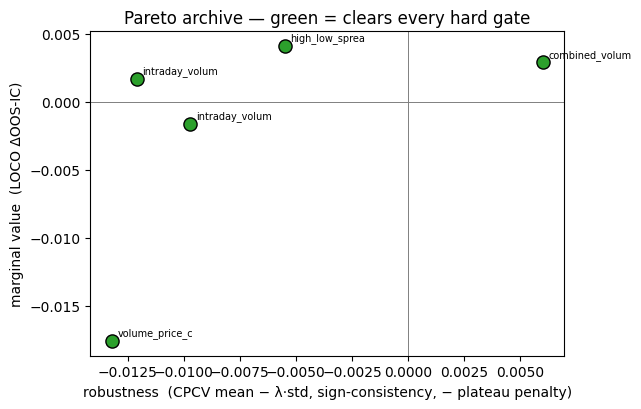

In [14]:
# the two axes the search trades off: marginal OOS edge vs robustness
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for _, r in archive_df.dropna(subset=["robustness", "marginal_value"]).iterrows():
    ax.scatter(r.robustness, r.marginal_value,
               s=90, c=("tab:green" if r.gate_pass else "tab:red"),
               edgecolor="k", zorder=3)
    ax.annotate(r.factor_id[:14], (r.robustness, r.marginal_value),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axhline(0, color="grey", lw=.7); ax.axvline(0, color="grey", lw=.7)
ax.set_xlabel("robustness  (CPCV mean − λ·std, sign-consistency, − plateau penalty)")
ax.set_ylabel("marginal value  (LOCO ΔOOS-IC)")
ax.set_title("Pareto archive — green = clears every hard gate")
plt.tight_layout(); plt.show()

In [15]:
# lineage: who each survivor descends from (the last few admitted genomes)
print("lineage tail (genome ← operator ← parents):")
for row in loop.controller.lineage[-6:]:
    print(f"  gen{row.get('generation')}  {row.get('operator'):11}  "
          f"{row.get('genome_id')}  ← {row.get('parent_ids') or '(seed)'}")

lineage tail (genome ← operator ← parents):
  gen1  llm_semantic  g1-volume_momentum_reversion-662806  ← ['g0-intraday_volume_momentum-78138e']
  gen2  llm_semantic  g2-closing_price_momentum_with_volume-1748b5  ← ['g0-closing_price_momentum-e19d47']
  gen2  jitter       g2-intraday_volume_momentum_j-f2f2ab  ← ['g0-intraday_volume_momentum-78138e']
  gen2  crossover    g2-combined_volume_momentum_correlation-b50534  ← ['g0-intraday_volume_momentum-78138e', 'g0-volume_price_correlation-a6acb8']
  gen3  llm_semantic  g3-volume_momentum_crash_indicator-05764c  ← ['g2-intraday_volume_momentum_j-f2f2ab']
  gen3  llm_semantic  g3-intraday_volume_momentum_crash-014396  ← ['g2-intraday_volume_momentum_j-f2f2ab']


## 11 · A second way to search — Quality-Diversity (MAP-Elites)

NSGA-II *converges*: the small Pareto front that drives parent selection pulls the
search toward a few winning lineages, so the discovered library can end up narrow.
**Quality-Diversity** takes the opposite stance — it deliberately keeps a *diverse*
library.

The idea (MAP-Elites): describe each factor by a few **behaviour descriptors** and
drop it into a cell of a grid keyed by those descriptors.  Here the grid is
**`trend_reversal` × `signal_speed`** (a third `stress_activation` axis is added at
`--grid-dims 3`):

* **`trend_reversal`** — does the signal fade recent moves (mean-reversion) or ride
  them (momentum)?
* **`signal_speed`** — is it slow and state-like, or fast and reactive?
* **`stress_activation`** — how much more strongly it fires on crash bars.

Crucially, the behaviour descriptors are computed by the harness but are **never
scored** — the *same* five-axis Pareto still measures quality.  Each grid cell holds a
small capped mini-Pareto of the best factors that *behave that way*, and parents are
sampled cell-first, then elite-within-cell.  The accepted book becomes the union of
every cell's elites: a spread of distinct behaviours rather than one converged front.

The cell below runs the same small configuration under `selection="qd"`, with two
diversity tweaks over the earlier NSGA-II run: a **slightly larger** search, and a
**finer behaviour grid** — 5 bins per axis instead of the 3-bin default, so survivors
that used to collapse into a single cell now separate.  Because parents are drawn from
behaviour cells (not a Pareto tournament), the children evolve along different lineages
— a genuinely different search.  The trace now also prints each candidate's behaviour
coordinates and the grid cell it lands in.


In [16]:
# Same trace + same fixed book, now under Quality-Diversity selection — plus two tweaks
# aimed at diversity: a slightly larger run, and a FINER behaviour grid (5 bins per axis
# instead of the 3-bin default) so survivors spread across more cells.
from quant_fund_agent.agents.factor_research.evolution.qd import QDArchive, QDConfig

FINE_TREND_EDGES = (-0.5, -0.15, 0.15, 0.5)   # 5 bins: strong fade … neutral … strong momentum
FINE_SPEED_EDGES = (0.4, 0.7, 1.0, 1.3)       # 5 bins: very slow … very fast

cfg_qd = EvolutionRunConfig(
    generations=3, population_size=8, children_per_generation=3,
    n_seed_ideas=5, seed_papers=0, retrieval="none",
    p_llm_semantic=0.6, p_crossover=0.2, p_jitter=0.2,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2,
    cpcv_groups=4, cpcv_k=2, embargo=0,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, seed=SEED,
    fixed_book=PRESETTLED_BOOK,
    out_dir=str(SCRATCH / "qd"),
    selection="qd", grid_dims=2, cell_capacity=3,   # ← MAP-Elites behaviour grid drives selection
    memory=True, memory_config=MEMORY_CONFIG,        # shares §9's memory file → cross-run accrual
)

loop_qd = EvolutionLoop(cfg_qd, data_context=DATA_CONTEXT, fields=FIELDS)
# swap in the finer grid BEFORE the run (the config default is 3 bins/axis; the QDConfig
# edge fields make it as fine as you like — see the note in §12 on the trade-off)
loop_qd.controller.qd = QDArchive(QDConfig(
    grid_dims=2, cell_capacity=cfg_qd.cell_capacity,
    trend_edges=FINE_TREND_EDGES, speed_edges=FINE_SPEED_EDGES))
loop_qd = attach_trace(loop_qd)

print(f"selection = {cfg_qd.selection}  |  behaviour grid = "
      f"{len(FINE_TREND_EDGES)+1}×{len(FINE_SPEED_EDGES)+1} (trend × speed), "
      f"capacity {cfg_qd.cell_capacity}/cell\n")
t0 = time.time()
summary_qd = loop_qd.run()          # ← real LLM + real ML; parents now sampled cell-first
qd = loop_qd.controller.qd
print(f"\n{'='*70}\nfinished in {time.time()-t0:.0f}s")
print(f"behaviour cells filled : {qd.n_cells()}   (occupancy {qd.occupancy()})")
print(f"accepted book (elites) : {len(qd.elites())} factor(s)   |   n_trials billed: "
      f"{loop_qd.controller.n_trials}")


evolution.loop     experience memory: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory/live_demo_sp100/graph.json (exhausted: none)
selection = qd  |  behaviour grid = 5×5 (trend × speed), capacity 3/cell

factor_research    [session evo-seed-7] brainstorm call (own-knowledge, asked 5, 3084 tok): 14.7s
evolution.loop     seeded 3/5 program(s) from 3 idea(s)
  gen0 seed        momentum_volume_ratio          marg +0.0026 indep -0.0375 robust -0.0072 regime -0.0104 | trend +0.14 speed +0.71  cell (2, 2)  PASS ✅
  gen0 seed        mean_reversion_high_low_spread marg +0.0037 indep -0.0244 robust -0.0145 regime +0.0127 | trend -0.02 speed +0.80  gate ✗ degradation
  gen0 seed        volatility_price_correlation   marg +0.0236 indep +0.0799 robust -0.0168 regime +0.0280 | trend +0.25 speed +0.18  cell (3, 0)  PASS ✅
evolution.loop     generation 0: population=3, archive=2, n_trials=3
  gen1 crossover   volatility_mean_reversion_corr marg +0.0047 indep +0.0429 ro

/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/quant_fund_agent/research_eval/harness.py:538: RuntimeWarning: Mean of empty slice
  s_mean = np.nanmean(zabs[s_rows])
/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/quant_fund_agent/research_eval/harness.py:539: RuntimeWarning: Mean of empty slice
  n_mean = np.nanmean(zabs[n_rows])


  gen3 llm_semanti momentum_volume_adjusted_2     marg -0.0011 indep   n/a  robust   n/a  regime -0.0054 | trend   n/a  speed   n/a   cell (0, 0)  PASS ✅


/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/quant_fund_agent/research_eval/harness.py:538: RuntimeWarning: Mean of empty slice
  s_mean = np.nanmean(zabs[s_rows])
/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent/quant_fund_agent/research_eval/harness.py:539: RuntimeWarning: Mean of empty slice
  n_mean = np.nanmean(zabs[n_rows])


  gen3 llm_semanti momentum_volume_adjusted_3     marg -0.0022 indep   n/a  robust   n/a  regime -0.0007 | trend   n/a  speed   n/a   cell (0, 0)  PASS ✅
  gen3 llm_semanti momentum_volume_decay          marg -0.0060 indep   n/a  robust -0.0995 regime -0.0047 | trend +0.76 speed +0.13  gate ✗ degradation
evolution.loop     generation 3: 3/3 children admitted; archive=4; n_trials=12
knowledge.graph_store saved knowledge graph (17 nodes, 12 edges) → /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory/live_demo_sp100/graph.json
evolution.loop     experience memory saved → /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory/live_demo_sp100/graph.json ({'mechanism': 5, 'factor': 12, 'edges': 12})

finished in 162s
behaviour cells filled : 4   (occupancy {'0|0': 2, '2|1': 1, '2|2': 1, '3|0': 3})
accepted book (elites) : 7 factor(s)   |   n_trials billed: 12


## 12 · The behaviour grid

The grid below is what Quality-Diversity keeps.  Each occupied cell is a distinct
*kind* of factor — a combination of trend behaviour and signal speed; its colour is
how many elites live there and its label the best marginal value found in that
behaviour.  Where NSGA-II collapses onto a single front, QD spreads survivors across
the behaviour space, so the final book can carry mean-reverters and momentum factors,
slow and fast, side by side.  The `stress_activation` descriptor is tracked in the
table too, and becomes a third grid axis at `--grid-dims 3`.

**On grid resolution.**  The default grid is 3 bins per axis (`trend_edges`,
`speed_edges`, `stress_edges` in `QDConfig`); this run overrides them to 5.  Finer
bins raise the diversity ceiling — more distinct niches to fill — but they also make
each cell sparser and lean harder on behaviour descriptors that are *estimated with
noise* on a small panel, so two near-identical factors can split across a boundary by
chance.  A good rule of thumb: scale bins with candidate count (coarse for a quick
demo, finer for a long thesis run with hundreds of evaluations).  It is worth making a
first-class run knob rather than a hard-coded default — see the note in §16.


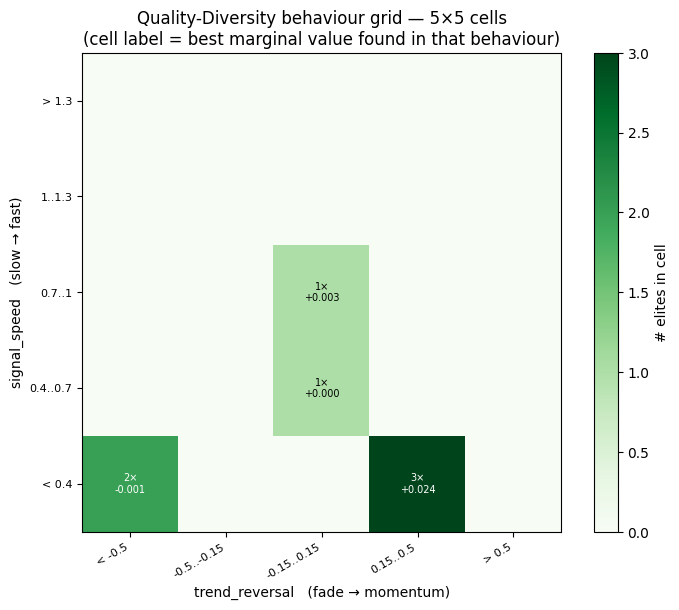

NSGA-II accepted book (Pareto front)      : 5 factor(s) — one converged front
QD accepted book (union of cell elites)   : 7 factor(s) across 4 behaviour cell(s)
QD-score (Σ best marginal value per cell) : +0.0256


,factor_id,cell,trend_reversal,signal_speed,stress_activation,marginal_value,independence,gen
0,volatility_price_correlation,0.15‥0.5 / < 0.4,0.246,0.183,1.06,0.0236,0.0799,0
1,volatility_mean_reversion_correlation,0.15‥0.5 / < 0.4,0.214,0.385,1.27,0.0047,0.0429,1
2,momentum_volume_ratio,-0.15‥0.15 / 0.7‥1,0.144,0.706,1.06,0.0026,-0.0375,0
3,momentum_volume_adjusted_1,-0.15‥0.15 / 0.4‥0.7,0.019,0.575,1.03,0.0004,0.0119,2
4,volatility_mean_reversion_price_correlation,0.15‥0.5 / < 0.4,0.214,0.385,1.27,0.0003,-0.0063,1
5,momentum_volume_adjusted_2,< -0.5 / < 0.4,NaN,NaN,NaN,-0.0011,NaN,3
6,momentum_volume_adjusted_3,< -0.5 / < 0.4,NaN,NaN,NaN,-0.0022,NaN,3


In [17]:
import numpy as np, matplotlib.pyplot as plt

qd = loop_qd.controller.qd

# read the grid geometry straight off the archive, so this works for ANY bin edges
t_edges, s_edges = list(qd.bin_edges["trend"]), list(qd.bin_edges["speed"])
n_tr, n_sp = len(t_edges) + 1, len(s_edges) + 1

def _bin_labels(edges):
    labs = [f"< {edges[0]:g}"]
    labs += [f"{a:g}‥{b:g}" for a, b in zip(edges[:-1], edges[1:])]
    labs += [f"> {edges[-1]:g}"]
    return labs
trend_labels, speed_labels = _bin_labels(t_edges), _bin_labels(s_edges)

# tally the accepted book (union of cell elites) onto the behaviour grid
counts = np.zeros((n_sp, n_tr)); best = np.full((n_sp, n_tr), np.nan)   # rows = speed, cols = trend
for eg in qd.elites():
    key = qd.cell_key(eg.fitness.behavior); tr, sp = key[0], key[1]
    counts[sp, tr] += 1
    mv = eg.fitness.objective.marginal_value
    if mv is not None:
        best[sp, tr] = mv if np.isnan(best[sp, tr]) else max(best[sp, tr], mv)

fig, ax = plt.subplots(figsize=(1.15 * n_tr + 1.8, 0.95 * n_sp + 1.4))
im = ax.imshow(counts, origin="lower", cmap="Greens", vmin=0)
ax.set_xticks(range(n_tr), trend_labels, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(n_sp), speed_labels, fontsize=8)
ax.set_xlabel("trend_reversal   (fade → momentum)")
ax.set_ylabel("signal_speed   (slow → fast)")
ax.set_title(f"Quality-Diversity behaviour grid — {n_tr}×{n_sp} cells\n"
             "(cell label = best marginal value found in that behaviour)")
for sp in range(n_sp):
    for tr in range(n_tr):
        if counts[sp, tr] > 0:
            ax.text(tr, sp, f"{int(counts[sp, tr])}×\n{best[sp, tr]:+.3f}",
                    ha="center", va="center", fontsize=7,
                    color=("white" if counts[sp, tr] > (counts.max() or 1) / 2 else "black"))
fig.colorbar(im, ax=ax, label="# elites in cell")
plt.tight_layout(); plt.show()

# the diverse accepted book: one row per elite, with its behaviour coordinates
def _rnd(x, nd=4):
    return round(x, nd) if isinstance(x, (int, float)) else np.nan

rows = []
for eg in qd.elites():
    b, o = eg.fitness.behavior, eg.fitness.objective
    key = qd.cell_key(b); tr, sp = key[0], key[1]
    rows.append({
        "factor_id": eg.genome.factor_ids[0],
        "cell": f"{trend_labels[tr]} / {speed_labels[sp]}",
        "trend_reversal": _rnd(b.get("trend_reversal"), 3),
        "signal_speed": _rnd(b.get("signal_speed"), 3),
        "stress_activation": _rnd(b.get("stress_activation"), 2),
        "marginal_value": _rnd(o.marginal_value),
        "independence": _rnd(o.independence),
        "gen": eg.genome.generation,
    })
qd_book = pd.DataFrame(rows)
if not qd_book.empty:
    qd_book = qd_book.sort_values("marginal_value", ascending=False).reset_index(drop=True)

print(f"NSGA-II accepted book (Pareto front)      : {len(loop.controller.archive)} factor(s) — one converged front")
print(f"QD accepted book (union of cell elites)   : {len(qd.elites())} factor(s) across {qd.n_cells()} behaviour cell(s)")
print(f"QD-score (Σ best marginal value per cell) : {qd.qd_score():+.4f}")
qd_book


## 13 · Building the knowledge graph (GraphRAG)

Everything so far grounded ideas in the model's own knowledge.  The **GraphRAG** layer
instead reads the *paper library* and fuses two graphs into one store: an
**LLM-extracted semantic layer** (`Paper → Mechanism → Field / Anomaly`, with mechanism
names canonicalised and clustered into communities) and a **computed layer**
(factor-correlation and field-usage edges added as factors are discovered).  Gap
queries over that graph — *which mechanisms do papers propose that no factor yet
exploits, and are computable from the fields we actually have?* — then steer the search
toward novel-but-buildable ideas.

A full build runs one extraction call per paper over the whole ~1 000-paper library
(`scripts/build_knowledge_graph.py`, resumable — already-ingested papers are skipped).
To keep this notebook cheap, the build below is deliberately **focused**: it extracts a
small cluster of papers on *signature transforms and rough-path / rough-volatility*
theory — the theme the steered session in §14 will chase.


In [18]:
from quant_fund_agent.knowledge.embed_store import load_corpus, EmbedStore
from quant_fund_agent.knowledge.graph_build import build_graph, detect_and_summarize_communities
from quant_fund_agent.knowledge import graph_query
from quant_fund_agent.llm import make_chat_llm

# 1) a cheap, deterministic embedding index over the WHOLE paper library (hash embedder,
#    offline; cached to disk after the first build) — this is what retrieval searches
corpus = load_corpus()
store = EmbedStore(corpus, embedder="hash").build()
print(f"embed store: {len(store.docs)} papers indexed ({store.embedder_name})\n")

# 2) curate a FOCUSED slice so the graph build stays cheap: papers on signature
#    transforms / rough paths / rough volatility — the theme §14 will chase
KEYWORDS = ("signature", "rough path", "rough vol", "fractional", "hurst", "roughness")
focus_docs = [d for d in corpus
              if any(k in (d.title + " " + (d.text or "")).lower() for k in KEYWORDS)][:8]
print(f"focused corpus for the graph build: {len(focus_docs)} paper(s)")
for d in focus_docs:
    print("   -", d.paper_id[:42].ljust(42), d.title[:50])

# 3) one LLM extraction call per paper → mechanisms / anomalies / needed fields
graph_llm = make_chat_llm(temperature=0.1, timeout=120, max_retries=3)
graph = build_graph(graph_llm, focus_docs, field_vocab=FIELDS)
detect_and_summarize_communities(graph)           # community detection + summaries (deterministic, no LLM)
graph.save(SCRATCH / "knowledge" / "graph.json")
print("\nknowledge graph:", graph.summary())

# the extracted semantic layer + the gap queries that steer the search
print("\nPaper → Mechanism → Field  (LLM-extracted, canonicalised):")
for m in sorted(graph.nodes_of_type("mechanism")):
    d = graph.g.nodes[m]
    needs = [f.split(":", 1)[1] for f in graph.fields_needed(m)]
    print(f"   • {d.get('name', '')[:46]:46}  "
          f"{len(graph.papers_for_mechanism(m))} paper(s)  needs={needs or '—'}")

gaps = graph_query.computable_unexploited(graph, FIELDS)
gap_names = [graph.g.nodes[m].get("name", m) for m in gaps]
print(f"\ncomputable-but-unexploited mechanisms ({len(gap_names)}) — gap queries steer the search here:")
for gname in gap_names[:12]:
    print("   ▸", gname)


knowledge.embed_store embedding 1014 papers (hash:v1) …
embed store: 1014 papers indexed (hash:v1)

focused corpus for the graph build: 8 paper(s)
   - volatility_is_rough                        Volatility is Rough
   - rough_paths_finance                        Rough Paths in Finance
   - factor_models_for_alpha_streams            Factor Models for Alpha Streams
   - hidden_order_in_trades_predicts_the_size_o Hidden Order in Trades Predicts the Size of Price 
   - correlation_of_coming_limit_price_with_ord Correlation of coming limit price with order book 
   - anomalous_diffusion_and_price_impact_in_th Anomalous diffusion and price impact in the fluid-
   - simulating_and_analyzing_a_sparse_order_bo Simulating and analyzing a sparse order book: an a
   - studies_of_the_limit_order_book_around_lar Studies of the limit order book around large price
knowledge.graph_build [graph_build] volatility_is_rough → 2 mechanism(s)
knowledge.graph_build [graph_build] rough_paths_finance → 2 mechan

## 14 · A steered researcher session (GraphRAG + a free-text brief)

The researcher can be handed an assignment in plain English — the way a portfolio
manager might brief a desk.  Here the brief is:

> *"I have been reading about signature transforms from rough-path theory and believe
> path signatures — and rough-volatility effects (fractional dynamics, a Hurst exponent
> well below 1/2) — carry real predictive power for future returns. Please invent
> factors that capture this."*

That brief does two jobs at once.  As the retrieval **focus** it pulls the matching
papers out of the embedding store, so the brainstorm is *grounded* in the
signature / rough-path literature rather than the model's vague memory of it; and the
GraphRAG **gap mechanisms** from §13 are attached as tags, so each idea names the
mechanism it exploits (closing the `Paper → Mechanism → Factor` provenance loop).  We
also fold the brief into the brainstorm context verbatim, so the model reads it as a
direct assignment.  The result is a set of factor ideas that are on-theme,
paper-grounded, and computable from the OHLCV fields — then written into real factor
code exactly as in §5.


In [19]:
from quant_fund_agent.knowledge.retrieval import retrieve_and_brainstorm
from quant_fund_agent.agents.factor_research.evolution.loop import coerce_idea, _codegen_program

# the plain-English assignment — exactly the kind of steer a PM might hand a desk
BRIEF = (
    "I have been reading about signature transforms from rough-path theory and I "
    "believe path signatures — together with rough-volatility effects (fractional "
    "dynamics, a Hurst exponent well below 1/2) — carry real predictive power for "
    "future returns. Please invent factors that capture this: signature-style path "
    "descriptors and roughness / fractional-volatility features, built only from the "
    "available price and volume bars."
)

# the brief plays two roles: a RESEARCH DIRECTIVE the brainstorm reads verbatim, and the
# retrieval `focus` that pulls the matching papers out of the embedding store
STEERED_CONTEXT = ("RESEARCH DIRECTIVE (from the portfolio manager)\n"
                   "-----------------------------------------------\n"
                   + textwrap.fill(BRIEF, 92) + "\n\n" + DATA_CONTEXT)

hyp_llm = make_chat_llm(temperature=0.7, timeout=120, max_retries=3)
ideas_raw = retrieve_and_brainstorm(
    hyp_llm, store,
    n_ideas=4, known_ids=set(), data_context=STEERED_CONTEXT,
    cardinality="1toN",              # each retrieved paper grounds its own idea (authoritative citation)
    k_papers=5,
    focus=BRIEF,                     # ← free-text steer for retrieval
    gaps=gap_names,                  # ← GraphRAG gap mechanisms weight the query
    mechanism_tags=gap_names,        # ← ask each idea to name the mechanism it exploits (provenance link-back)
)
print(f"steered brainstorm returned {len(ideas_raw)} idea(s), grounded in the signature/rough-path papers\n")
for r in ideas_raw:
    print("──", r.get("factor_id"), "| mechanism:", r.get("mechanism"),
          "| grounded in:", r.get("source_paper_ids"))
    print("  ", textwrap.fill(r.get("trading_idea", ""), 92, subsequent_indent="   "), "\n")

# write the on-theme ideas into real factor code — the same in-memory codegen as §5
codegen_llm = make_chat_llm(temperature=0.2, timeout=120, max_retries=3)
steered_progs = []
for r in ideas_raw:
    idea = coerce_idea(r, HORIZON)
    if idea is None:
        continue
    prog = _codegen_program(codegen_llm, idea, STEERED_CONTEXT)
    if prog is not None:
        steered_progs.append(prog)
        print(f"compiled  {prog.factor_id:34.34} horizon {prog.prediction_horizon}  "
              f"sign {prog.expected_sign}  ({prog.category})")

print(f"\n{len(steered_progs)} steered factor(s) compiled from the signature/rough-path brief.")
print("(these could now be handed straight to EvolutionLoop(initial_programs=steered_progs) "
      "to evolve exactly like the seeds in §9.)")
if steered_progs:
    print("=" * 92)
    print(steered_progs[0].code)


knowledge.retrieval retrieved 5 paper(s) [returns_and_order_flow_imbalances_intraday_dynamics_and_macr, market_dynamics_vs_statistics_limit_order_book_example, stochastic_price_dynamics_implied_by_the_limit_order_book, stochastic_order_book_modelling, price_dynamics_in_a_markovian_limit_order_market] for cardinality=1toN
steered brainstorm returned 4 idea(s), grounded in the signature/rough-path papers

── rough_signature_imbalance | mechanism: None | grounded in: ['returns_and_order_flow_imbalances_intraday_dynamics_and_macr']
   This factor captures the relationship between price movements and order flow imbalances
   using signature transforms to identify rough volatility dynamics. The concept is rooted
   in the understanding that significant price changes often correlate with imbalances in
   order flow, particularly in volatile conditions, as noted in the research on returns and
   order flow dynamics. By analyzing these relationships through signature-based
   descriptors, we ca

## 15 · Experience memory — what worked, what didn't

A run should *learn across runs*.  With memory switched on, every scored candidate is
tallied against its mechanism/topic — **survivors and failures alike** — on a
per-config memory graph.  The failures are the load-bearing part: a topic tried many
times that rarely survives is *exhausted*, and the next run is steered away from it (a
survivor-only record could never tell an exhausted topic from an unexplored one).  The
best survivors and a short "what's promising / what's exhausted" brief are spliced into
the next run's teacher channel.

The NSGA-II run (§9) and the QD run (§11) both had memory switched on and share one
memory file, so the table below is what the machine recorded **across both runs**.
(The file lives under the scratch dir and keeps accumulating on every re-run — delete
`SCRATCH/memory/` to reset.)  In these tiny runs the topic is the factor's category;
in a GraphRAG run it is the extracted mechanism name, so the memory speaks the same
vocabulary as §13's graph.


In [20]:
import pandas as pd
from quant_fund_agent.knowledge import experience
from IPython.display import display

mem_path = experience.memory_graph_path(MEMORY_CONFIG)
mem = experience.load_or_new(mem_path)
print("experience memory :", mem_path)
print("graph             :", mem.summary(), "\n")

# per-topic attempt/survival tallies — survivors AND failures (the negative evidence
# that lets the memory tell an EXHAUSTED topic from an unexplored one)
rows = []
for mid in mem.nodes_of_type("mechanism"):
    nd = mem.g.nodes[mid]
    n = int(nd.get("n_attempts", 0) or 0)
    rows.append({
        "topic": nd.get("name", mid.split(":", 1)[-1]),
        "n_attempts": n,
        "n_survived": int(nd.get("n_survived", 0) or 0),
        "survival_rate": round(int(nd.get("n_survived", 0) or 0) / n, 2) if n else None,
        "best_marginal": nd.get("best_marginal"),
        "last_gen": nd.get("last_generation"),
    })
tally = (pd.DataFrame(rows).sort_values(["n_attempts", "best_marginal"], ascending=False)
         .reset_index(drop=True)) if rows else pd.DataFrame()
print("what the two runs recorded, by topic (worked well = high survival-rate & best_marginal):")
display(tally)

# survivors stamped with their realized performance
surv = [(mem.g.nodes[f].get("name", f.split(":", 1)[-1]),
         mem.g.nodes[f].get("realized_marginal_value"),
         mem.g.nodes[f].get("realized_val_ic"))
        for f in mem.nodes_of_type("factor")]
if surv:
    print("\nsurvivors kept (topic-tagged factors), best realized marginal value first:")
    for name, mv, ic in sorted(surv, key=lambda t: (t[1] if t[1] is not None else -9), reverse=True):
        print(f"   - {name:38.38}  realized marginal "
              f"{'n/a' if mv is None else f'{mv:+.4f}'}   val_ic "
              f"{'n/a' if ic is None else f'{ic:+.4f}'}")

# the teacher brief spliced into the NEXT run + the exhaustion steer
print("\nteacher summary (spliced into the next run's reflection / debate):")
print("  ", experience.memory_summary(mem) or "(nothing recorded yet)")
print("\nexhausted topics — production τ (≥5 attempts, ≤25% survival):",
      experience.exhausted_mechanisms(mem) or "none yet")
print("exhausted topics — demo τ (≥2 attempts):",
      experience.exhausted_mechanisms(mem, min_attempts=2) or "none at this threshold")


experience memory : /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution/memory/live_demo_sp100/graph.json
graph             : {'mechanism': 5, 'factor': 12, 'edges': 12} 

what the two runs recorded, by topic (worked well = high survival-rate & best_marginal):


,topic,n_attempts,n_survived,survival_rate,best_marginal,last_gen
0,momentum,15,7,0.47,0.008211,3
1,volatility,4,3,0.75,0.023627,1
2,statistical_arbitrage,3,1,0.33,0.013000,1
3,mean_reversion,2,1,0.50,0.004127,0
4,microstructure,1,0,0.00,-0.001297,0



survivors kept (topic-tagged factors), best realized marginal value first:
   - volatility_price_correlation            realized marginal +0.0236   val_ic +0.0453
   - volatility_mean_reversion_correlation   realized marginal +0.0047   val_ic +0.0525
   - high_low_spread_reversion               realized marginal +0.0041   val_ic +0.0413
   - combined_volume_momentum_correlation    realized marginal +0.0029   val_ic +0.0415
   - momentum_volume_ratio                   realized marginal +0.0026   val_ic -0.0156
   - intraday_volume_momentum_j              realized marginal +0.0017   val_ic -0.0034
   - momentum_volume_adjusted_1              realized marginal +0.0004   val_ic +0.0098
   - volatility_mean_reversion_price_correl  realized marginal +0.0003   val_ic +0.0525
   - momentum_volume_adjusted_2              realized marginal -0.0011   val_ic n/a
   - intraday_volume_momentum                realized marginal -0.0016   val_ic +0.0033
   - momentum_volume_adjusted_3              rea

## 16 · From here to a thesis run

That was the whole machine in miniature, running for real — both selection strategies,
the GraphRAG knowledge layer, a steered session, and the cross-run memory.  Nothing
here was persisted into the repo — `persist_archive(...)` is what materialises the
final book into `data/workspaces/<config>/preruns/<name>/`, after which the comparison
and walk-forward harnesses score it exactly like a one-shot prerun.

To scale the *same* objects up (papers, islands, a stronger model, RAG/GraphRAG
grounding, the Hypothesis→Debate→Codegen split, and **two-stage curation**):

```bash
# build the knowledge graph once (one extraction call per paper; resumable), then a run
python scripts/build_knowledge_graph.py --max-papers 200

# a real evolution prerun (persisted); GraphRAG-grounded, memory on, curate a 12-factor book
python run_factor_evolution.py --name evo1 --generations 12 --population 12 \
    --children-per-gen 10 --islands 2 --seed-papers 6 --retrieval graphrag --memory \
    --debate on --model gpt-4o --curation greedy --n-keep 12 \
    --fixed-book data/workspaces/yfinance_equity_sp100/prebooks/lasso_prebook.json

# the same run under Quality-Diversity selection (a diverse behaviour-grid library)
python run_factor_evolution.py --name evo1_qd --generations 12 --population 12 \
    --children-per-gen 10 --selection qd --grid-dims 2 --cell-capacity 3 --memory \
    --fixed-book data/workspaces/yfinance_equity_sp100/prebooks/lasso_prebook.json

# then walk-forward validation of the whole loop
python run_factor_evolution.py --name evo1 --walk-forward 2023-01-01,2024-01-01,2025-01-01
```

`--fixed-book` conditions candidate fitness on the Lasso book without persisting those factors as discoveries.

`--retrieval graphrag` steers seeding automatically toward the graph's *computable
gap* mechanisms; `--memory` turns on the cross-run experience memory of §15.  The
free-text **steered brief** of §14 works through the retrieval `focus` seam
(`retrieve_and_brainstorm(..., focus=...)`) — handy inside a notebook or a small
driver script; wiring it to a `--brief` CLI flag is a small, worthwhile extension.

`--selection nsga2` (the default) converges onto the Pareto front; `--selection qd`
fills the behaviour grid instead (`--grid-dims 3` adds the `stress_activation` axis) —
a clean ablation dimension for the results chapter.  The grid **bin edges** are still
`QDConfig` defaults (3 bins/axis); §12 overrides them in-notebook.  Promoting them to
run flags (`--trend-edges/--speed-edges`, or a single `--grid-bins N`) is the clean way
to make the axes finer for a large run without touching the defaults the tests pin.

`--curation archive` (the default) persists the Pareto front (the one-stage
behaviour); `--curation greedy|elastic_net` persists the curated `kept_pool`
instead, so a good factor is not discarded merely for being dominated.  The
independence axis defaults to residual IC (`--independence-metric
delta_participation` restores the legacy Δ-participation-ratio for an ablation),
and the regime axis is configurable via `--regime-kind {drawdown,volatility}`.

For the conceptual deep-dive on each component (splits, deflation, the 5-axis
objective vector, the NSGA-II controller, the QD behaviour grid, GraphRAG, the
experience memory, two-stage curation) see the companion notebook
`evolutionary_factor_researcher_walkthrough.ipynb`.
